In [1]:
import pandas as pd
import numpy as np

# original = pd.read_csv('C:\\Users\\KN2C\\Desktop\\Dani\\relbench\\original.csv')
# input = pd.read_csv('C:\\Users\\KN2C\\Desktop\\Dani\\relbench\\input.csv')

# result = pd.read_csv('C:\\Users\\KN2C\\Desktop\\Dani\\relbench\\result.csv')

# merged_df = pd.merge(result, input, on='customers_id', how='inner')  # 'inner' join by default


In [31]:
original

,SaleTime,articles_id,price_purchase,Quantity,BranchCode,customers_id,takhfif,Payment channel,Sales channel,week,price_basket,datetime
0,23:29:45,303,99500.0,1.0,13808,9120800148,0.0,0,حضوری,0,155200.0,2022-01-01
1,23:29:45,501,39500.0,1.0,13808,9120800148,0.0,0,حضوری,0,155200.0,2022-01-01
2,23:29:45,602,16200.0,2.0,13808,9120800148,0.0,0,حضوری,0,155200.0,2022-01-01
3,17:51:41,602,16200.0,2.0,13803,9127963133,0.0,1,حضوری,0,133200.0,2022-01-01
4,17:51:41,501,39500.0,1.0,13803,9127963133,0.0,1,حضوری,0,133200.0,2022-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...
4638330,15:51:15,903,194500.0,1.0,13814,9351555271,0.0,1,حضوری,135,218500.0,2024-08-02
4638331,15:51:15,604,24000.0,1.0,13814,9351555271,0.0,1,حضوری,135,218500.0,2024-08-02
4638332,16:23:22,101,242500.0,1.0,13814,9173058935,0.0,1,حضوری,135,272500.0,2024-08-02
4638333,16:23:22,641,30000.0,1.0,13814,9173058935,0.0,1,حضوری,135,272500.0,2024-08-02


In [32]:
input

,SaleTime,articles_id,price_purchase,Quantity,BranchCode,customers_id,takhfif,Payment channel,Sales channel,week,price_basket,datetime
0,23:29:45,17,99500.0,1.0,3,115012,0.0,0,حضوری,0,155200.0,2022-01-01
1,23:29:45,1,39500.0,1.0,3,115012,0.0,0,حضوری,0,155200.0,2022-01-01
2,23:29:45,30,16200.0,2.0,3,115012,0.0,0,حضوری,0,155200.0,2022-01-01
3,17:51:41,30,16200.0,2.0,0,475472,0.0,1,حضوری,0,133200.0,2022-01-01
4,17:51:41,1,39500.0,1.0,0,475472,0.0,1,حضوری,0,133200.0,2022-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...
4603163,17:46:51,70,115500.0,1.0,3,493974,0.0,2,اسنپ,134,367000.0,2024-07-25
4603164,17:46:51,125,251500.0,1.0,3,493974,0.0,2,اسنپ,134,367000.0,2024-07-25
4603165,14:42:01,204,339500.0,1.0,12,131742,0.0,2,اسنپ,134,387500.0,2024-07-25
4603166,14:42:01,4,48000.0,2.0,12,131742,0.0,2,اسنپ,134,387500.0,2024-07-25


In [33]:
# Perform the merge using multiple columns (name, age, purchase_amount)
merged_df1 = pd.merge(original, input, on=['SaleTime', 'price_purchase', 'Quantity', 'takhfif', 'Payment channel', 'Sales channel', 'week',
       'price_basket', 'datetime'], how='inner', suffixes=('_df1', '_df2'))

# # Extract the customers_id from df2 and map it to df1
# input['customers_id_mapped'] = merged_df1['customers_id_df2']

In [34]:
merged_df1

,SaleTime,articles_id_df1,price_purchase,Quantity,BranchCode_df1,customers_id_df1,takhfif,Payment channel,Sales channel,week,price_basket,datetime,articles_id_df2,BranchCode_df2,customers_id_df2
0,23:29:45,303,99500.0,1.0,13808,9120800148,0.0,0,حضوری,0,155200.0,2022-01-01,17,3,115012
1,23:29:45,501,39500.0,1.0,13808,9120800148,0.0,0,حضوری,0,155200.0,2022-01-01,1,3,115012
2,23:29:45,602,16200.0,2.0,13808,9120800148,0.0,0,حضوری,0,155200.0,2022-01-01,30,3,115012
3,17:51:41,602,16200.0,2.0,13803,9127963133,0.0,1,حضوری,0,133200.0,2022-01-01,30,0,475472
4,17:51:41,501,39500.0,1.0,13803,9127963133,0.0,1,حضوری,0,133200.0,2022-01-01,1,0,475472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5177313,17:46:51,308,115500.0,1.0,13808,9128373937,0.0,2,اسنپ,134,367000.0,2024-07-25,70,3,493974
5177314,17:46:51,109,251500.0,1.0,13808,9128373937,0.0,2,اسنپ,134,367000.0,2024-07-25,125,3,493974
5177315,14:42:01,324,339500.0,1.0,13813,9121087906,0.0,2,اسنپ,134,387500.0,2024-07-25,204,12,131742
5177316,14:42:01,601,48000.0,2.0,13813,9121087906,0.0,2,اسنپ,134,387500.0,2024-07-25,4,12,131742


In [36]:
# Extract the customers_id from df2 and map it to df1
mapping = merged_df1[['customers_id_df1', 'customers_id_df2', 'articles_id_df1','articles_id_df2']]

In [38]:
mapping

,customers_id_df1,customers_id_df2,articles_id_df1,articles_id_df2
0,9120800148,115012,303,17
1,9120800148,115012,501,1
2,9120800148,115012,602,30
3,9127963133,475472,602,30
4,9127963133,475472,501,1
...,...,...,...,...
5177313,9128373937,493974,308,70
5177314,9128373937,493974,109,125
5177315,9121087906,131742,324,204
5177316,9121087906,131742,601,4


In [40]:
mapped_df = pd.merge(result, mapping[['customers_id_df2', 'customers_id_df1']], left_on='customers_id', right_on='customers_id_df2', how='left')

# Now, the 'customers_id_df1' column contains the original 'customers_id' from df2 (mapped to df1)
mapped_df = mapped_df[['customers_id_df1', 'predicted_churn']]

In [42]:
mapped_df.drop_duplicates()

,customers_id_df1,predicted_churn
0,9392298297,10.108130
2,9392429812,3.573477
52,9392534899,3.517277
65,9393274819,1.025772
89,9394385318,7.288265
...,...,...
302674,9192255696,1.736018
302678,9193002391,6.216950
302683,9193244858,1.785985
302743,9025878824,7.340096


In [43]:
mapped_df['churn_label'] = (mapped_df['predicted_churn'] > 0.5).astype(int)


In [46]:
out = mapped_df.drop_duplicates()

In [48]:
out.to_csv('C:\\Users\\KN2C\Desktop\\Dani\\relbench\\output.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\KN2C\AppData\Local\Temp\ipykernel_12520\4122335677.py:1: SyntaxWarning: invalid escape sequence '\D'
  out.to_csv('C:\\Users\\KN2C\Desktop\\Dani\\relbench\\output.csv')


In [39]:
result

,customers_id,predicted_churn
0,820105,10.108130
1,820432,3.573477
2,820663,3.517277
3,822402,1.025772
4,824978,7.288265
...,...,...
10989,600080,2.724762
10990,603426,1.736018
10991,607081,6.216950
10992,608889,1.785985


In [7]:
input

,SaleTime,articles_id,price_purchase,Quantity,BranchCode,customers_id,takhfif,Payment channel,Sales channel,week,price_basket,datetime
0,23:29:45,17,99500.0,1.0,3,115012,0.0,0,حضوری,0,155200.0,2022-01-01
1,23:29:45,1,39500.0,1.0,3,115012,0.0,0,حضوری,0,155200.0,2022-01-01
2,23:29:45,30,16200.0,2.0,3,115012,0.0,0,حضوری,0,155200.0,2022-01-01
3,17:51:41,30,16200.0,2.0,0,475472,0.0,1,حضوری,0,133200.0,2022-01-01
4,17:51:41,1,39500.0,1.0,0,475472,0.0,1,حضوری,0,133200.0,2022-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...
4603163,17:46:51,70,115500.0,1.0,3,493974,0.0,2,اسنپ,134,367000.0,2024-07-25
4603164,17:46:51,125,251500.0,1.0,3,493974,0.0,2,اسنپ,134,367000.0,2024-07-25
4603165,14:42:01,204,339500.0,1.0,12,131742,0.0,2,اسنپ,134,387500.0,2024-07-25
4603166,14:42:01,4,48000.0,2.0,12,131742,0.0,2,اسنپ,134,387500.0,2024-07-25


In [2]:
original = pd.read_csv('D:\Dani\\relbench\\relbench\\burger_data\\trans\\transaction_data.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\KN2C\AppData\Local\Temp\ipykernel_18600\1627980249.py:1: SyntaxWarning: invalid escape sequence '\D'
  original = pd.read_csv('D:\Dani\\relbench\\relbench\\burger_data\\trans\\transaction_data.csv')


In [3]:
original

,date,SaleTime,customers_id,art_name,factor_id,d_dat,articles_id,Quantity,price_item,takhfif,...,Num,Sales channel,BranchName,BranchCode,FoodType,FoodTypeName,price_purchase,Total_Quantity,basketprice,group_id
0,1401-01-02,20:39:14,9373875028,کوکاکولا خانواده,1.401010e+17,2022-03-22 20:39:14,611,1.0,14300.0,0.0,...,1549664.0,اسنپ فود,تهرانپارس,13802,600,نوشيدني ها,14300.0,4.0,255002.0,600
1,1401-01-02,15:03:14,9128458569,کوکاکولا خانواده,1.401010e+17,2022-03-22 15:03:14,611,1.0,14300.0,0.0,...,1549582.0,اسنپ فود,تهرانپارس,13802,600,نوشيدني ها,14300.0,4.0,317501.0,600
2,1401-01-02,15:01:29,9197069885,پيتزا پنجره اي,1.401010e+17,2022-03-22 15:01:29,306,1.0,90500.0,0.0,...,1549580.0,اسنپ فود,تهرانپارس,13802,300,پيتزا,90500.0,1.0,110500.0,300
3,1401-01-02,15:00:35,9125849235,ماشروم برگر,1.401010e+17,2022-03-22 15:00:35,104,3.0,89500.0,0.0,...,1549578.0,اسنپ فود,تهرانپارس,13802,100,برگرها,268500.0,11.0,621499.0,100
4,1401-01-02,15:00:35,9125849235,کوکاکولا خانواده,1.401010e+17,2022-03-22 15:00:35,611,1.0,14300.0,0.0,...,1549578.0,اسنپ فود,تهرانپارس,13802,600,نوشيدني ها,14300.0,11.0,621499.0,600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5068232,1403-09-13,13:33:54,995555555696674,دابل جوسي اسموکي برگر,1.403091e+17,2024-12-03 13:33:54,153,1.0,374500.0,37450.0,...,511.0,اسنپ فود,هايپر استار,13807,190,جوسي ها,374500.0,3.0,660999.0,190
5068233,1403-09-13,14:13:21,9361850719,سوپر پيتزا رست بيف,1.403091e+17,2024-12-03 14:13:21,323,1.0,364500.0,0.0,...,506.0,مشترکين,شعبه بازار (پرنسا),13814,320,سوپر پيتزا,364500.0,3.0,1123501.0,320
5068234,1403-09-13,12:32:39,9122267893,کوکا کولا قوطي,1.403091e+17,2024-12-03 12:32:39,601,1.0,23190.0,0.0,...,502.0,مشترکين,شعبه بازار (پرنسا),13814,600,نوشيدني ها,23190.0,3.0,388000.0,600
5068235,1403-09-13,12:32:39,9122267893,سيب زميني مخصوص,1.403091e+17,2024-12-03 12:32:39,501,1.0,109500.0,0.0,...,502.0,مشترکين,شعبه بازار (پرنسا),13814,500,پيش غذاها,109500.0,3.0,388000.0,500


In [4]:
df = pd.DataFrame(original)

In [5]:
df['d_dat'] = pd.to_datetime(df['d_dat'])

In [6]:
df['d_dat'].max

<bound method Series.max of 0         2022-03-22 20:39:14
1         2022-03-22 15:03:14
2         2022-03-22 15:01:29
3         2022-03-22 15:00:35
4         2022-03-22 15:00:35
                  ...        
5068232   2024-12-03 13:33:54
5068233   2024-12-03 14:13:21
5068234   2024-12-03 12:32:39
5068235   2024-12-03 12:32:39
5068236   2024-12-03 12:32:39
Name: d_dat, Length: 5068237, dtype: datetime64[ns]>

In [7]:
df['d_dat'].min

<bound method Series.min of 0         2022-03-22 20:39:14
1         2022-03-22 15:03:14
2         2022-03-22 15:01:29
3         2022-03-22 15:00:35
4         2022-03-22 15:00:35
                  ...        
5068232   2024-12-03 13:33:54
5068233   2024-12-03 14:13:21
5068234   2024-12-03 12:32:39
5068235   2024-12-03 12:32:39
5068236   2024-12-03 12:32:39
Name: d_dat, Length: 5068237, dtype: datetime64[ns]>

In [21]:
# Define the exception row (the one that should not be removed)
exception_row = {
    'date': '1403-09-13',
    'SaleTime': '14:27:28',
    'customers_id': 9121147227,
    'art_name': 'کوکاکولا خانواده',
    'factor_id': 1.401010e+17,
    'd_dat': pd.to_datetime('2024-12-03 14:27:28'),
    'articles_id': 902,
    'Quantity': 1.0,
    'price_item': 14300.0,
    'takhfif': 0.0,
    'Num': 1098.0,
    'Sales channel': 'اسنپ فود',
    'BranchName': 'تهرانپارس',
    'BranchCode': 13811,
    'FoodType': 600,
    'FoodTypeName': 'نوشيدني ها',
    'price_purchase': 14300.0,
    'Total_Quantity': 1.0,
    'basketprice': 310000.0,
    'group_id': 600
}

# Convert the exception row 'd_dat' to datetime format
exception_row['d_dat'] = pd.to_datetime(exception_row['d_dat'])

# Filter out rows before 2024-11-26, except for the exception row
df_filtered = df[df['d_dat'] <= pd.to_datetime('2024-11-26')]

# Filter the removed rows (dates < 2024-11-26)
df_removed = df[df['d_dat'] > pd.to_datetime('2024-11-26')]

# Check if the exception row is in the removed data, if so, remove it from df_removed
if not df_removed[df_removed['d_dat'] == exception_row['d_dat']].empty:
    df_removed = df_removed[df_removed['d_dat'] != exception_row['d_dat']]

# Add the exception row back to the filtered data
df_filtered = pd.concat([df_filtered, pd.DataFrame([exception_row])], ignore_index=True)

# Save the removed data to a new CSV file
df_removed.to_csv('removed_data.csv', index=False)

# Display the filtered and removed data
print("Filtered Data (kept data):")
print(df_filtered)

print("\nRemoved Data (saved to 'removed_data.csv'):")
print(df_removed)

Filtered Data (kept data):
               date  SaleTime     customers_id                  art_name  \
0        1401-01-02  20:39:14       9373875028          کوکاکولا خانواده   
1        1401-01-02  15:03:14       9128458569          کوکاکولا خانواده   
2        1401-01-02  15:01:29       9197069885            پيتزا پنجره اي   
3        1401-01-02  15:00:35       9125849235               ماشروم برگر   
4        1401-01-02  15:00:35       9125849235          کوکاکولا خانواده   
...             ...       ...              ...                       ...   
5034343  1403-09-05  22:42:36       9129313017  فيله استريپس  چهار  تيکه   
5034344  1403-09-05  19:57:33       9914644427            کوکا کولا قوطي   
5034345  1403-09-05  21:30:43  995555555685465       سوپر پيتزا چهار فصل   
5034346  1403-09-05  17:17:30  995555555692742                  مگا برگر   
5034347  1403-09-13  14:27:28       9121147227          کوکاکولا خانواده   

            factor_id               d_dat  articles_id  Quan

In [8]:
# Define the synthetic row for the date '2024-12-10 14:27:28'
synthetic_row = {
    'date': '1403-09-19',  # Adjust as needed (optional)
    'SaleTime': '14:27:28',
    'customers_id': 9121147227,
    'art_name': 'کوکاکولا خانواده',
    'factor_id': 1.401010e+17,
    'd_dat': pd.to_datetime('2024-12-10 14:27:28'),  # Set the new date
    'articles_id': 902,
    'Quantity': 1.0,
    'price_item': 14300.0,
    'takhfif': 0.0,
    'Num': 1098.0,
    'Sales channel': 'اسنپ فود',
    'BranchName': 'تهرانپارس',
    'BranchCode': 13811,
    'FoodType': 600,
    'FoodTypeName': 'نوشيدني ها',
    'price_purchase': 14300.0,
    'Total_Quantity': 1.0,
    'basketprice': 310000.0,
    'group_id': 600
}

# Add the synthetic row to the DataFrame df
df = pd.concat([df, pd.DataFrame([synthetic_row])], ignore_index=True)

# Now df contains the synthetic row for '2024-12-10 14:27:28'
print(df)


               date  SaleTime  customers_id            art_name     factor_id  \
0        1401-01-02  20:39:14    9373875028    کوکاکولا خانواده  1.401010e+17   
1        1401-01-02  15:03:14    9128458569    کوکاکولا خانواده  1.401010e+17   
2        1401-01-02  15:01:29    9197069885      پيتزا پنجره اي  1.401010e+17   
3        1401-01-02  15:00:35    9125849235         ماشروم برگر  1.401010e+17   
4        1401-01-02  15:00:35    9125849235    کوکاکولا خانواده  1.401010e+17   
...             ...       ...           ...                 ...           ...   
5068233  1403-09-13  14:13:21    9361850719  سوپر پيتزا رست بيف  1.403091e+17   
5068234  1403-09-13  12:32:39    9122267893      کوکا کولا قوطي  1.403091e+17   
5068235  1403-09-13  12:32:39    9122267893     سيب زميني مخصوص  1.403091e+17   
5068236  1403-09-13  12:32:39    9122267893    سوپر برگر ماشروم  1.403091e+17   
5068237  1403-09-19  14:27:28    9121147227    کوکاکولا خانواده  1.401010e+17   

                      d_dat

In [9]:
df.to_csv('synTrans.csv', index=False)

In [24]:
# Save the removed data to a new CSV file
df_filtered.to_csv('filtered_data.csv', index=False)

In [22]:
df_sorted_desc = df_filtered.sort_values(by='d_dat', ascending=False)

In [23]:
df_sorted_desc


,date,SaleTime,customers_id,art_name,factor_id,d_dat,articles_id,Quantity,price_item,takhfif,...,Num,Sales channel,BranchName,BranchCode,FoodType,FoodTypeName,price_purchase,Total_Quantity,basketprice,group_id
5034347,1403-09-13,14:27:28,9121147227,کوکاکولا خانواده,1.401010e+17,2024-12-03 14:27:28,902,1.0,14300.0,0.0,...,1098.0,اسنپ فود,تهرانپارس,13811,600,نوشيدني ها,14300.0,1.0,310000.0,600
5031009,1403-09-05,23:55:16,9121033674,کوکا کولا قوطي,1.403091e+17,2024-11-25 23:55:16,601,1.0,23190.0,0.0,...,1160140.0,حضوري,پاسداران,13803,600,نوشيدني ها,23190.0,3.0,472000.0,600
5031010,1403-09-05,23:55:16,9121033674,ماشروم برگر,1.403091e+17,2024-11-25 23:55:16,104,1.0,266500.0,0.0,...,1160140.0,حضوري,پاسداران,13803,100,برگرها,266500.0,3.0,472000.0,100
5031015,1403-09-05,23:55:16,9121033674,هات داگ,1.403091e+17,2024-11-25 23:55:16,901,1.0,189500.0,0.0,...,1160140.0,حضوري,پاسداران,13803,900,هات داگ,189500.0,3.0,472000.0,900
5034247,1403-09-05,23:45:28,9028490053,پيتزا مخصوص,1.403091e+18,2024-11-25 23:45:28,301,1.0,289500.0,0.0,...,2528449.0,اسنپ فود,تهرانپارس,13802,300,پيتزا,289500.0,2.0,534000.0,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3954,1401-01-02,01:03:27,9121835587,اسپرايت خانواده,1.401010e+17,2022-03-22 01:03:27,612,1.0,14300.0,0.0,...,555420.0,اسنپ فود,جم سنتر,13810,600,نوشيدني ها,14300.0,4.0,272501.0,600
3949,1401-01-02,01:03:27,9121835587,سيب زميني مخصوص,1.401010e+17,2022-03-22 01:03:27,501,1.0,44500.0,0.0,...,555420.0,اسنپ فود,جم سنتر,13810,500,پيش غذاها,44500.0,4.0,272501.0,500
3965,1401-01-02,01:03:27,9121835587,جوسي برگر,1.401010e+17,2022-03-22 01:03:27,103,2.0,88500.0,0.0,...,555420.0,اسنپ فود,جم سنتر,13810,100,برگرها,177000.0,4.0,272501.0,100
3950,1401-01-02,01:01:37,9123096989,جوسي برگر,1.401010e+17,2022-03-22 01:01:37,103,2.0,88500.0,0.0,...,555418.0,اسنپ فود,جم سنتر,13810,100,برگرها,177000.0,2.0,201000.0,100


In [20]:
df_removed

,date,SaleTime,customers_id,art_name,factor_id,d_dat,articles_id,Quantity,price_item,takhfif,...,Num,Sales channel,BranchName,BranchCode,FoodType,FoodTypeName,price_purchase,Total_Quantity,basketprice,group_id
5034347,1403-09-06,00:08:06,9121329407,دابل جوسي برگر,1.403091e+17,2024-11-26 00:08:06,113,1.0,364500.0,0.0,...,1186590.0,مشترکين,بيهقي,13811,150,دابل برگرها,364500.0,2.0,573500.0,150
5034348,1403-09-06,15:59:18,9129613703,کوکا کولا قوطي,1.403091e+17,2024-11-26 15:59:18,601,1.0,23190.0,0.0,...,1594929.0,مشترکين,سعادت آباد,13805,600,نوشيدني ها,23190.0,2.0,447500.0,600
5034349,1403-09-06,15:14:48,9016380353,لند برگر,1.403091e+17,2024-11-26 15:14:48,101,1.0,253500.0,0.0,...,1594921.0,مشترکين,سعادت آباد,13805,100,برگرها,253500.0,3.0,436999.0,100
5034350,1403-09-06,15:14:48,9016380353,سيب زميني مخصوص,1.403091e+17,2024-11-26 15:14:48,501,1.0,109500.0,0.0,...,1594921.0,مشترکين,سعادت آباد,13805,500,پيش غذاها,109500.0,3.0,436999.0,500
5034351,1403-09-06,22:07:07,9141214559,سوپر برگر ماشروم,1.403091e+17,2024-11-26 22:07:07,1138,1.0,312500.0,0.0,...,1595030.0,مشترکين,سعادت آباد,13805,201,سوپر برگر,312500.0,3.0,516499.0,201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5068232,1403-09-13,13:33:54,995555555696674,دابل جوسي اسموکي برگر,1.403091e+17,2024-12-03 13:33:54,153,1.0,374500.0,37450.0,...,511.0,اسنپ فود,هايپر استار,13807,190,جوسي ها,374500.0,3.0,660999.0,190
5068233,1403-09-13,14:13:21,9361850719,سوپر پيتزا رست بيف,1.403091e+17,2024-12-03 14:13:21,323,1.0,364500.0,0.0,...,506.0,مشترکين,شعبه بازار (پرنسا),13814,320,سوپر پيتزا,364500.0,3.0,1123501.0,320
5068234,1403-09-13,12:32:39,9122267893,کوکا کولا قوطي,1.403091e+17,2024-12-03 12:32:39,601,1.0,23190.0,0.0,...,502.0,مشترکين,شعبه بازار (پرنسا),13814,600,نوشيدني ها,23190.0,3.0,388000.0,600
5068235,1403-09-13,12:32:39,9122267893,سيب زميني مخصوص,1.403091e+17,2024-12-03 12:32:39,501,1.0,109500.0,0.0,...,502.0,مشترکين,شعبه بازار (پرنسا),13814,500,پيش غذاها,109500.0,3.0,388000.0,500


## Evaluation

In [ ]:
import pandas as pd
import numpy as np

df_pred = pd.read_csv('C:\\Users\\KN2C\\Desktop\\Dani\\relbench\\result_filtered.csv')
df_pred['customers_id'] = df_pred['mapped_customers_id']
df_trans = pd.read_csv('C:\\Users\\KN2C\\Desktop\\Dani\\relbench\\removed_data.csv')

In [55]:
# Step 1: Create a set of customers who made transactions
customers_with_transactions = set(df_trans['customers_id'])

# Step 2: Generate the ground truth label
# If the customer is in the transaction data, the label is 0 (transaction made)
# If the customer is not in the transaction data, the label is 1 (no transaction)
df_pred['ground_truth_label'] = df_pred['customers_id'].apply(
    lambda x: 0 if x in customers_with_transactions else 1
)

# Display the result
print(df_pred)


          customers_id  predicted_churn  mapped_customers_id  label  \
0      995555555689621         3.526111      995555555689621      1   
1      995555555689745         3.815355      995555555689745      1   
2      995555555689553         1.444606      995555555689553      1   
3      995555555689611         2.192217      995555555689611      1   
4      995555555689594         3.897572      995555555689594      1   
...                ...              ...                  ...    ...   
87391       9129730408         2.930706           9129730408      1   
87392  995555555592795         1.488630      995555555592795      1   
87393       9123250697         3.010447           9123250697      1   
87394  995555555592893         4.208570      995555555592893      1   
87395       9123959248         4.101174           9123959248      1   

       ground_truth_label  
0                       1  
1                       1  
2                       1  
3                       1  
4      

In [51]:
df_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33889 entries, 0 to 33888
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            33889 non-null  object 
 1   SaleTime        33889 non-null  object 
 2   customers_id    33889 non-null  int64  
 3   art_name        33889 non-null  object 
 4   factor_id       33889 non-null  float64
 5   d_dat           33889 non-null  object 
 6   articles_id     33889 non-null  int64  
 7   Quantity        33889 non-null  float64
 8   price_item      33889 non-null  float64
 9   takhfif         33889 non-null  float64
 10  Service         33889 non-null  float64
 11  Maliat          33889 non-null  float64
 12  NetAmount       33889 non-null  float64
 13  Num             33889 non-null  float64
 14  Sales channel   33889 non-null  object 
 15  BranchName      33889 non-null  object 
 16  BranchCode      33889 non-null  int64  
 17  FoodType        33889 non-null 

In [52]:
df_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customers_id         87396 non-null  int64  
 1   predicted_churn      87396 non-null  float64
 2   mapped_customers_id  87396 non-null  int64  
 3   label                87396 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 2.7 MB


In [58]:
from sklearn.metrics import confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_merged already contains 'predicted_label' and 'ground_truth_label'

# Extract the predicted labels and ground truth labels
y_pred = df_pred['label']
y_true = df_pred['ground_truth_label']

# Calculate evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Accuracy: 0.9425
Precision: 0.9483
Recall: 0.9932
F1-Score: 0.9702


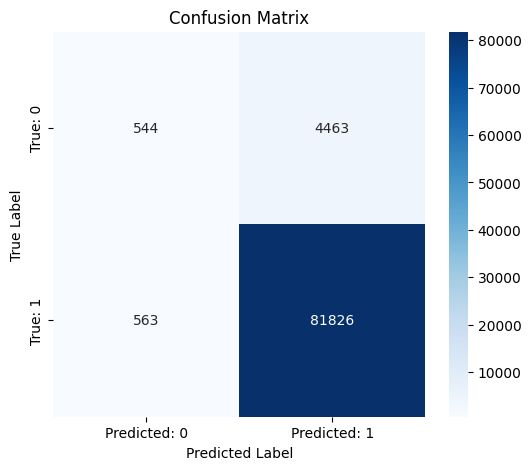

Confusion Matrix:
[[  544  4463]
 [  563 81826]]
ROC AUC Score: 0.5509


In [59]:
# Step 1: Calculate the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Step 2: Calculate the ROC AUC score
# For ROC AUC, we need predicted probabilities (not just labels).
# So, assuming you have probability scores, here we will simulate a model 
# using predicted labels (0 or 1) as scores for simplicity.

# If you have probabilities, you would use them like this:
# roc_auc = roc_auc_score(y_true, y_pred_probabilities)

# Here we're using the predicted label itself as the score (0 or 1)
roc_auc = roc_auc_score(y_true, y_pred)

# Step 3: Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Predicted: 0", "Predicted: 1"], 
            yticklabels=["True: 0", "True: 1"])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

# Print the confusion matrix and ROC AUC score
print("Confusion Matrix:")
print(conf_matrix)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Recommendation

In [19]:
import pandas as pd
import numpy as np

map = pd.read_csv('D:\\Dani\\relbench\\relbench\\hyper_data\\Articles.csv')
result = pd.read_csv('C:\\Users\\KN2C\\Desktop\\Dani\\ContextGNN\\result_recom.csv')

# merged_df = pd.merge(result, input, on='customers_id', how='inner')  # 'inner' join by default


In [20]:
map.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44901 entries, 0 to 44900
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   articles_id           44901 non-null  float64
 1   art_name              44901 non-null  object 
 2   Item Barcode          44901 non-null  object 
 3   External Item Number  44901 non-null  object 
 4   Department Name       44901 non-null  object 
 5   group                 44901 non-null  object 
 6   Subgroup Name         44901 non-null  object 
 7   group_id              44901 non-null  int64  
 8   whole_Branch_Name     44901 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 3.1+ MB


In [22]:
# Convert the articles_id column to int64
map['articles_id'] = map['articles_id'].astype('int64')

# Check the result
print(map.dtypes)


articles_id              int64
art_name                object
Item Barcode            object
External Item Number    object
Department Name         object
group                   object
Subgroup Name           object
group_id                 int64
whole_Branch_Name       object
dtype: object


In [23]:
map

,articles_id,art_name,Item Barcode,External Item Number,Department Name,group,Subgroup Name,group_id,whole_Branch_Name
0,35157919,اصالت آبلیمو 900 گرمی,6260273700395.0,6260273700395.0,FMCG - کالای بسته بندی,سرکه و آبلیمو,آبلیمو,86,Dry Food - مواد غذایی بسته بندی
1,217206954,رامک پنیر سفید پروبیوتیک 400 گرمی,6260074000472.0,6260074000472.0,FMCG - کالای بسته بندی,انواع پنیر,انواع پنیر سفید,18,OPSS - یخچالی و انجمادی
2,989227168,تخم مرغ طلقی فله,2205436.0,2205436.0,Fresh - تازه فروشی,تخم ماکیان فله,انواع تخم مرغ فله,33,پروتئینی فله
3,2011346,سس گلوریا 88 گرم فلفل زرد تند,6263348100069.0,6263348100069.0,FMCG - کالای بسته بندی,انواع سس,سس فلفل,10,Dry Food - مواد غذایی بسته بندی
4,2006610,فانتا نوشابه لیمویی1500 سی سی پت,6260265100523.0,6260265100523.0,FMCG - کالای بسته بندی,انواع نوشابه,انواع نوشابه پت بزرگ سایر طعم ها,11,Beverage - نوشیدنی ها
...,...,...,...,...,...,...,...,...,...
44896,1063730579,رینوزیت مام رول 50 میل مردانه شماره 21 هوگو بوس,6262821504325,6262821504325,FMCG - کالای بسته بندی,خوشبو کننده بدن,مام رول آقایان,88,DPH -آرایشی و بهداشتی
44897,1073730872,سحر ترشی آلبالو شیشه 250 گرمی,6260308300637,6260308300637,FMCG - کالای بسته بندی,ترشیجات و چاشنی,ترشیجات ساده,105,Dry Food - مواد غذایی بسته بندی
44898,1083731512,سام آرشیت ماناتونیک زنانه زنجیردار,2022383,2022383,Textile - پوشاک، منسوجات، کیف و کفش,پوشاک زنانه,پیراهن زنانه,118,انواع پوشاک
44899,1091734656,سام آرشیت مانابلوز بچه گانه مد کد 950 بغل مشکی...,2022682,2022682,Textile - پوشاک، منسوجات، کیف و کفش,پوشاک بچه گانه و نوزاد,پیراهن بچه گانه و نوزاد,137,انواع پوشاک


In [27]:
result

,customers_id_x,predicted_articles,mapped_articles_id_x,mapped_customers_id,customers_id_y,groundtruth_articles,mapped_articles_id_y
0,290678,[ 25 643 426 32],"[2006600, 2001760, 1005731906, 2013897]",9907001027,290678,[16161 13080 1207 17820 182 367 1491],"[1222743017, 2014581, 2007600, 1313744505, 200..."
1,204080,[15992 16180 2120 5235],"[1205742547, 1234743559, 246208736, 2026396]",9153860682,204080,[10409 3600 7535],"[4130860, 4130445, 8135758]"
2,37584,[ 869 230 8209 32],"[72675749, 2024176, 4130051, 2013897]",9132504656,37584,[12457 12468 179 1966 12741],"[1018738187, 1018738181, 2013223, 168203400, 1..."
3,290702,[ 25 426 643 126],"[2006600, 1005731906, 2001760, 2026442]",9114824062,290702,[ 523 53 1154 234 1807 6733 10053 19...,"[163202620, 2005500, 2006604, 252, 1009732597,..."
4,290706,[ 25 643 426 204],"[2006600, 2001760, 1005731906, 2005418]",9153119555,290706,[ 1315 16764 16081 3587 4518 8795],"[2016403, 1130740311, 792219404, 6134260, 3515..."
...,...,...,...,...,...,...,...
15537,95767,[15867 505 1539 526],"[1204742435, 32152237, 2014019, 2016375]",9128325841,95767,[6453],[4130849]
15538,290062,[ 25 643 426 204],"[2006600, 2001760, 1005731906, 2005418]",9011504179,290062,[18542],[1345745528]
15539,290084,[ 25 426 643 126],"[2006600, 1005731906, 2001760, 2026442]",9121315248,290084,[10780],[180204077]
15540,16252,[ 4273 1966 15956 2189],"[1005731897, 168203400, 991728393, 2012787]",9191325528,16252,[12616],[958226067]


In [26]:
import ast

# Step 1: Convert string representation of lists into actual lists (if necessary)
result['mapped_articles_id_x'] = result['mapped_articles_id_x'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
result['mapped_articles_id_y'] = result['mapped_articles_id_y'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Apply the conversion to each element inside the lists
result['mapped_articles_id_x'] = result['mapped_articles_id_x'].apply(
    lambda x: [int(article) for article in x] if isinstance(x, list) else x
)

result['mapped_articles_id_y'] = result['mapped_articles_id_y'].apply(
    lambda x: [int(article) for article in x] if isinstance(x, list) else x
)

# Step 3: Convert the columns to int64, making sure the data is correctly formatted
result['mapped_articles_id_x'] = result['mapped_articles_id_x'].apply(pd.Series).stack().astype('int64')
result['mapped_articles_id_y'] = result['mapped_articles_id_y'].apply(pd.Series).stack().astype('int64')

# Check the result
print(result.dtypes)


TypeError: incompatible index of inserted column with frame index

In [28]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15542 entries, 0 to 15541
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customers_id_x        15542 non-null  int64 
 1   predicted_articles    15542 non-null  object
 2   mapped_articles_id_x  15542 non-null  object
 3   mapped_customers_id   15542 non-null  int64 
 4   customers_id_y        15542 non-null  int64 
 5   groundtruth_articles  15542 non-null  object
 6   mapped_articles_id_y  15542 non-null  object
dtypes: int64(3), object(4)
memory usage: 850.1+ KB


In [29]:
# Assuming df1 is the DataFrame with the columns 'mapped_articles_id_x' and 'mapped_articles_id_y'
# Assuming df2 is the DataFrame with the columns 'articles_id' and 'art_name'

# 1. Create reverse mapping from articles_id to art_name in df2
article_to_name_map = pd.Series(map['art_name'].values, index=map['articles_id']).to_dict()

# 2. Map 'mapped_articles_id_x' and 'mapped_articles_id_y' to 'art_name'
result['mapped_articles_name_x'] = result['mapped_articles_id_x'].map(article_to_name_map)
result['mapped_articles_name_y'] = result['mapped_articles_id_y'].map(article_to_name_map)

# View the updated DataFrame
print(result[['mapped_articles_id_x', 'mapped_articles_name_x', 'mapped_articles_id_y', 'mapped_articles_name_y']].head())


TypeError: unhashable type: 'list'

In [31]:
# Assuming article_to_name_map is already defined
# Reverse mapping from articles_id to art_name
article_to_name_map = pd.Series(map['art_name'].values, index=map['articles_id']).to_dict()

# Step 1: Apply reverse mapping to each article ID inside the list (for 'mapped_articles_id_x')
result['mapped_articles_name_x'] = result['mapped_articles_id_x'].apply(
    lambda x: [article_to_name_map.get(article, article) for article in x]
)

# Step 2: Apply reverse mapping to each article ID inside the list (for 'mapped_articles_id_y')
result['mapped_articles_name_y'] = result['mapped_articles_id_y'].apply(
    lambda x: [article_to_name_map.get(article, article) for article in x]
)

# View the updated DataFrame
print(result[['mapped_articles_id_x', 'mapped_articles_name_x', 'mapped_articles_id_y', 'mapped_articles_name_y']].head())


                           mapped_articles_id_x  \
0       [2006600, 2001760, 1005731906, 2013897]   
1  [1205742547, 1234743559, 246208736, 2026396]   
2         [72675749, 2024176, 4130051, 2013897]   
3       [2006600, 1005731906, 2001760, 2026442]   
4       [2006600, 2001760, 1005731906, 2005418]   

                              mapped_articles_name_x  \
0  [کوکاکولا نوشابه پت 1500 سی سی, پپسی نوشابه پت...   
1  [گوشت شیشک گوسفندی, نان بربری, بی نظیر برنج ها...   
2  [مرغ گرم تنظیم بازار, پگاه کره 50 گرمی داخلی, ...   
3  [کوکاکولا نوشابه پت 1500 سی سی, گل شکر شکر 1 ک...   
4  [کوکاکولا نوشابه پت 1500 سی سی, پپسی نوشابه پت...   

                                mapped_articles_id_y  \
0  [1222743017, 2014581, 2007600, 1313744505, 200...   
1                        [4130860, 4130445, 8135758]   
2  [1018738187, 1018738181, 2013223, 168203400, 1...   
3  [163202620, 2005500, 2006604, 252, 1009732597,...   
4  [2016403, 1130740311, 792219404, 6134260, 3515...   

                   

In [32]:
result

,customers_id_x,predicted_articles,mapped_articles_id_x,mapped_customers_id,customers_id_y,groundtruth_articles,mapped_articles_id_y,mapped_articles_name_x,mapped_articles_name_y
0,290678,[ 25 643 426 32],"[2006600, 2001760, 1005731906, 2013897]",9907001027,290678,[16161 13080 1207 17820 182 367 1491],"[1222743017, 2014581, 2007600, 1313744505, 200...","[کوکاکولا نوشابه پت 1500 سی سی, پپسی نوشابه پت...","[تاپیس کروتون کچاپ ویژه 20 عددی, کاله بستنی چو..."
1,204080,[15992 16180 2120 5235],"[1205742547, 1234743559, 246208736, 2026396]",9153860682,204080,[10409 3600 7535],"[4130860, 4130445, 8135758]","[گوشت شیشک گوسفندی, نان بربری, بی نظیر برنج ها...","[گوشت تخت شده گوساله, قند فله, توینینگز چای سن..."
2,37584,[ 869 230 8209 32],"[72675749, 2024176, 4130051, 2013897]",9132504656,37584,[12457 12468 179 1966 12741],"[1018738187, 1018738181, 2013223, 168203400, 1...","[مرغ گرم تنظیم بازار, پگاه کره 50 گرمی داخلی, ...",[بابانا کیک دولایه اسفنجی کاکائویی با مغزی کرم...
3,290702,[ 25 426 643 126],"[2006600, 1005731906, 2001760, 2026442]",9114824062,290702,[ 523 53 1154 234 1807 6733 10053 19...,"[163202620, 2005500, 2006604, 252, 1009732597,...","[کوکاکولا نوشابه پت 1500 سی سی, گل شکر شکر 1 ک...","[تافته نوار ویژه شب مشبک, چی توز اسنک طلایی پذ..."
4,290706,[ 25 643 426 204],"[2006600, 2001760, 1005731906, 2005418]",9153119555,290706,[ 1315 16764 16081 3587 4518 8795],"[2016403, 1130740311, 792219404, 6134260, 3515...","[کوکاکولا نوشابه پت 1500 سی سی, پپسی نوشابه پت...","[مینو آدامس وایت جعبه ای نعناع 25 گرمی, دلپذیر..."
...,...,...,...,...,...,...,...,...,...
15537,95767,[15867 505 1539 526],"[1204742435, 32152237, 2014019, 2016375]",9128325841,95767,[6453],[4130849],[کاوه - ماسک پزشکی 3 لایه یکبار مصرف جعبه 50 ع...,[آبگوشتی گوسفندی]
15538,290062,[ 25 643 426 204],"[2006600, 2001760, 1005731906, 2005418]",9011504179,290062,[18542],[1345745528],"[کوکاکولا نوشابه پت 1500 سی سی, پپسی نوشابه پت...",[پاکناز - مایع دستشوئی 3750 گرمی سبز]
15539,290084,[ 25 426 643 126],"[2006600, 1005731906, 2001760, 2026442]",9121315248,290084,[10780],[180204077],"[کوکاکولا نوشابه پت 1500 سی سی, گل شکر شکر 1 ک...",[بن آدو ناگت مرغ سوخاری 950گرم]
15540,16252,[ 4273 1966 15956 2189],"[1005731897, 168203400, 991728393, 2012787]",9191325528,16252,[12616],[958226067],[شیرین عسل شکلات مغزدار با دراژه شکلاتی دریم ا...,[صدرا شیرمال مخصوص]


In [33]:
result.to_csv('C:\\Users\\KN2C\Desktop\\Dani\\contextgnn\\result_recom_with_name.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\KN2C\AppData\Local\Temp\ipykernel_18628\761833348.py:1: SyntaxWarning: invalid escape sequence '\D'
  result.to_csv('C:\\Users\\KN2C\Desktop\\Dani\\contextgnn\\result_recom_with_name.csv', index=False)


In [34]:
result.to_excel('C:\\Users\\KN2C\Desktop\\Dani\\contextgnn\\result_recom_with_name.xlsx', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\KN2C\AppData\Local\Temp\ipykernel_18628\2382329139.py:1: SyntaxWarning: invalid escape sequence '\D'
  result.to_excel('C:\\Users\\KN2C\Desktop\\Dani\\contextgnn\\result_recom_with_name.xlsx', index=False)
